# 04. Modeling, Evaluation, and Report Figures

This notebook runs the strict temporal modeling pipeline and creates report-ready figures inline. Each figure is displayed at the point where it is created and then saved to `reports/figures/` from the same matplotlib figure object.

Target definition: `negative_label = 1` when `future_negative_count > future_positive_count` in the future label window.

## 1. Setup

Load project modules, define artifact paths, and make sure outputs are written to the standard repo folders.

In [1]:
from pathlib import Path
import importlib
import sys

import pandas as pd

root = Path.cwd()
if not (root / 'data').exists():
    root = root.parent
sys.path.insert(0, str(root))

import src.phase3 as phase3
import src.visualization as viz

phase3 = importlib.reload(phase3)
viz = importlib.reload(viz)

phase1_path = root / 'data' / 'processed' / 'phase1' / 'phase1_kcore_filtered.csv'
phase2_dir = root / 'data' / 'processed' / 'phase2'
phase3_dir = root / 'data' / 'processed' / 'phase3'
figure_dir = root / 'reports' / 'figures'

phase3_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)

{
    'project_root': str(root),
    'python_executable': sys.executable,
    'xgboost_available': phase3.XGBClassifier is not None,
    'lightgbm_available': phase3.LGBMClassifier is not None,
    'phase1_input': str(phase1_path),
    'phase3_output_dir': str(phase3_dir),
    'figure_dir': str(figure_dir),
}

{'project_root': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning',
 'python_executable': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\.venv\\Scripts\\python.exe',
 'xgboost_available': True,
 'lightgbm_available': True,
 'phase1_input': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase1\\phase1_kcore_filtered.csv',
 'phase3_output_dir': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase3',
 'figure_dir': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Predict

## 2. Run Strict Temporal Modeling

Features are computed only from history windows, while labels are computed from disjoint future windows. Future label counts are excluded from the feature matrix to avoid data leakage.

In [2]:
interactions = phase3.load_phase1_interactions(phase1_path)
metrics_frame, importance_frame, score_frame, splits = phase3.run_phase3_pipeline(interactions)
paths = phase3.export_phase3_outputs(metrics_frame, importance_frame, phase3_dir, score_frame)

run_summary = {
    'train_rows': len(splits.train),
    'validation_rows': len(splits.validation),
    'test_rows': len(splits.test),
    'metric_rows': len(metrics_frame),
    'models': sorted(metrics_frame['model'].unique().tolist()),
    'feature_sets': sorted(metrics_frame['feature_set'].unique().tolist()),
    'importance_rows': len(importance_frame),
    'score_rows': len(score_frame),
    'export_paths': {key: str(value) for key, value in paths.items()},
}
run_summary

{'train_rows': 25045,
 'validation_rows': 26450,
 'test_rows': 24185,
 'metric_rows': 41,
 'models': ['dummy_most_frequent',
  'dummy_prior',
  'historical_negative_ratio',
  'lightgbm',
  'logistic_regression',
  'random_forest',
  'xgboost'],
 'feature_sets': ['graph_no_balance',
  'graph_only',
  'history_only',
  'hybrid',
  'hybrid_no_balance',
  'text_only'],
 'importance_rows': 2634,
 'score_rows': 2076035,
 'export_paths': {'metrics': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase3\\phase3_model_metrics.csv',
  'importance': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase3\\phase3_feature_importance.csv',
  'scores': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Lin

## 3. Model Comparison Table

The main metric is PR-AUC because negative-dominant relationships are rare. ROC-AUC, F1, precision, recall, balanced accuracy, and confusion counts are used as supporting metrics.

In [3]:
metric_columns = [
    'feature_set', 'model',
    'test_pr_auc', 'test_roc_auc', 'test_f1', 'test_macro_f1',
    'test_precision', 'test_recall', 'test_balanced_accuracy', 'test_accuracy',
    'test_threshold', 'test_tn', 'test_fp', 'test_fn', 'test_tp', 'n_features',
]
metrics_frame[metric_columns].head(50)

,feature_set,model,test_pr_auc,test_roc_auc,test_f1,test_macro_f1,test_precision,test_recall,test_balanced_accuracy,test_accuracy,test_threshold,test_tn,test_fp,test_fn,test_tp,n_features
0,hybrid,logistic_regression,0.183965,0.756889,0.269986,0.593465,0.204978,0.395376,0.640194,0.850858,0.72,19911,2587,1020,667,133
1,hybrid_no_balance,logistic_regression,0.183672,0.756065,0.269658,0.592391,0.202747,0.402490,0.641906,0.847922,0.71,19828,2670,1008,679,128
2,graph_only,logistic_regression,0.181181,0.750823,0.262524,0.577570,0.180901,0.478364,0.657975,0.812528,0.63,18844,3654,880,807,44
3,graph_no_balance,logistic_regression,0.180749,0.749555,0.264000,0.574871,0.178267,0.508595,0.666401,0.802191,0.61,18543,3955,829,858,39
4,hybrid,lightgbm,0.179214,0.762595,0.256013,0.584824,0.192584,0.381743,0.630866,0.845235,0.19,19798,2700,1043,644,133
5,graph_no_balance,lightgbm,0.178420,0.760506,0.260528,0.574248,0.177250,0.491405,0.660184,0.805417,0.17,18650,3848,858,829,39
6,graph_only,lightgbm,0.177255,0.759236,0.249907,0.577959,0.181941,0.398933,0.632216,0.832954,0.19,19472,3026,1014,673,44
7,hybrid,xgboost,0.175451,0.753152,0.234777,0.575442,0.181436,0.332543,0.610022,0.848791,0.20,19967,2531,1126,561,133
8,graph_only,xgboost,0.174134,0.756554,0.253587,0.578165,0.181795,0.419087,0.638826,0.827910,0.20,19316,3182,980,707,44
9,hybrid_no_balance,lightgbm,0.173634,0.760980,0.259302,0.576737,0.179817,0.464730,0.652891,0.814803,0.16,18922,3576,903,784,128


## 4. Model Comparison Figure

This plot is displayed inline first, then saved as `model_comparison_pr_auc.png`.

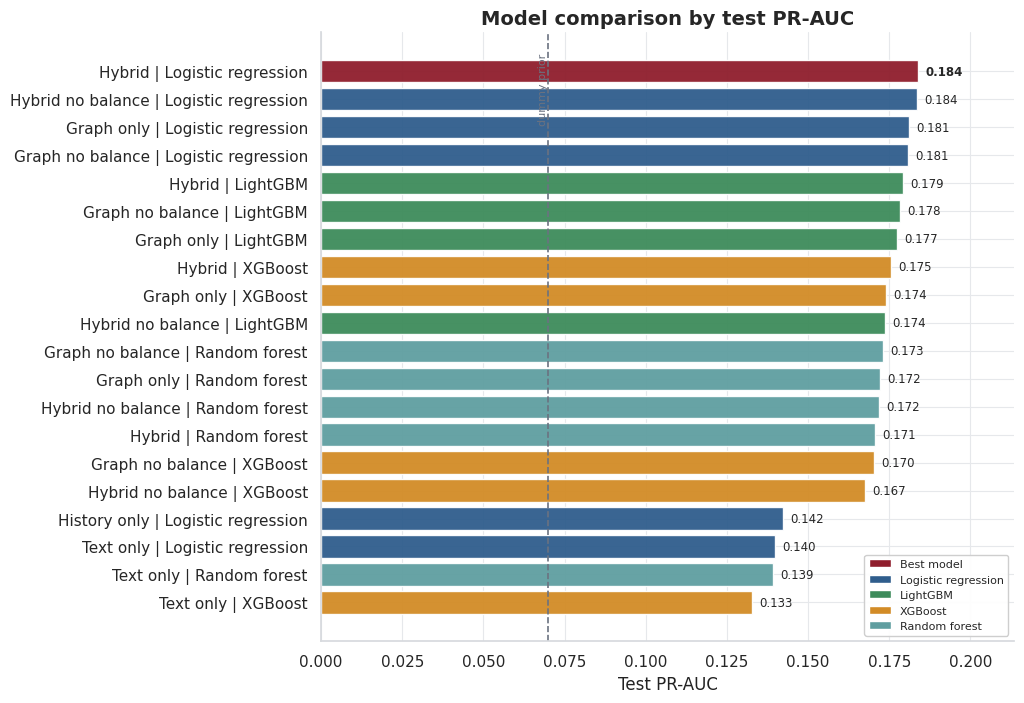

WindowsPath('H:/chuong_trinh_hoc_UEH/mon_hoc_ki_6/social_media_data_analysis/Project/Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning/reports/figures/model_comparison_pr_auc.png')

In [4]:
figure_paths = {}
figure_paths['model_comparison'] = viz.plot_model_comparison(metrics_frame, figure_dir, show=True)
figure_paths['model_comparison']

## 5. Precision-Recall and ROC Curves

The precision-recall curve is most informative for the rare negative class. The ROC curve is included as a supporting ranking-quality view.

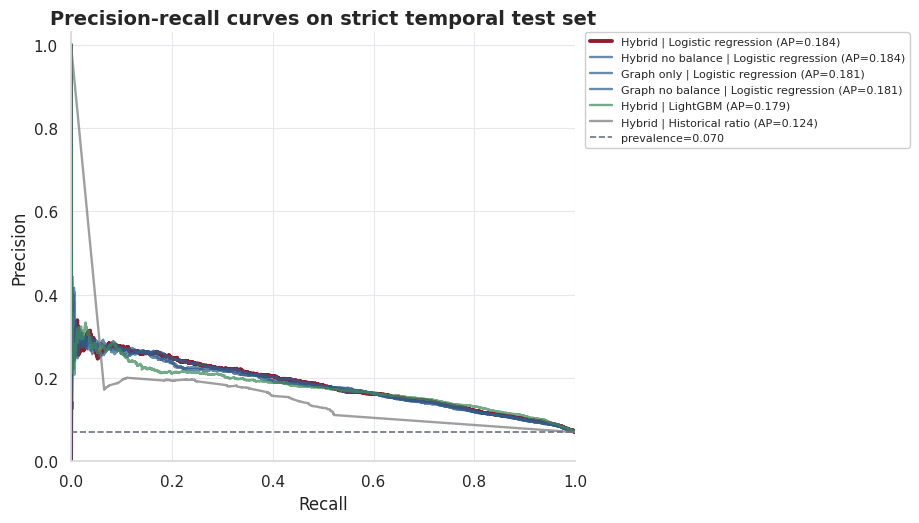

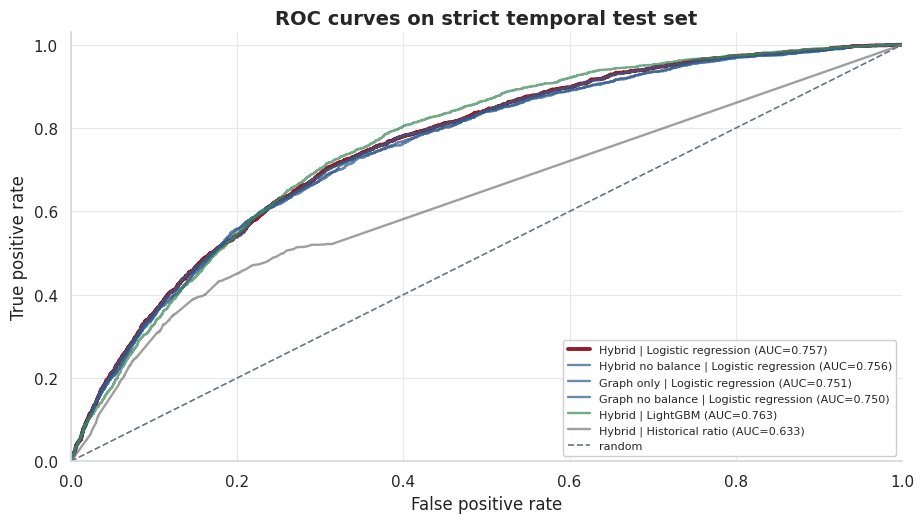

{'precision_recall_curve': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\precision_recall_curve.png',
 'roc_curve': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\roc_curve.png'}

In [5]:
figure_paths['precision_recall_curve'] = viz.plot_precision_recall_curve(score_frame, metrics_frame, figure_dir, show=True)
figure_paths['roc_curve'] = viz.plot_roc_curve(score_frame, metrics_frame, figure_dir, show=True)
{
    'precision_recall_curve': str(figure_paths['precision_recall_curve']),
    'roc_curve': str(figure_paths['roc_curve']),
}

## 6. Best Model, Confusion Matrix, and Feature Importance

The confusion matrix shows the concrete true/false positives and negatives. The feature-importance plot explains which signals drive the best non-baseline model.

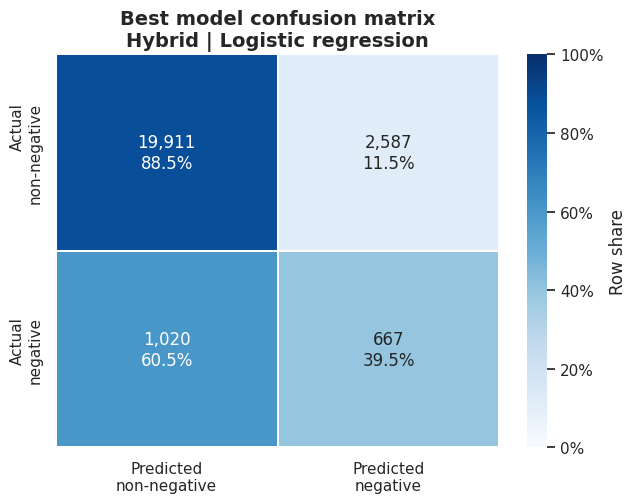

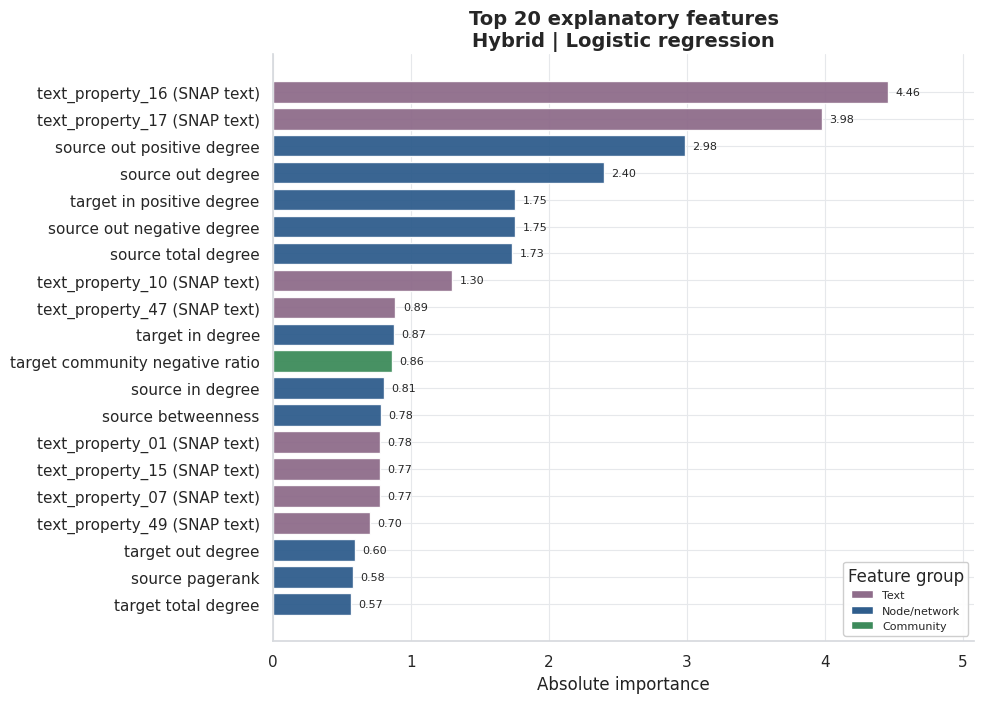

{'best_feature_set': 'hybrid',
 'best_model': 'logistic_regression',
 'test_pr_auc': 0.1839651743610894,
 'test_roc_auc': 0.7568887767300978,
 'test_f1': 0.2699858328273629,
 'test_precision': 0.20497848801475108,
 'test_recall': 0.3953764078245406,
 'confusion_counts': {'tn': 19911, 'fp': 2587, 'fn': 1020, 'tp': 667},
 'top_features': [{'feature': 'text_property_16',
   'importance': 4.456538774550899},
  {'feature': 'text_property_17', 'importance': 3.9799495068295574},
  {'feature': 'source_out_positive_degree', 'importance': 2.9835149428199337},
  {'feature': 'source_out_degree', 'importance': 2.396460740472307},
  {'feature': 'target_in_positive_degree', 'importance': 1.7539560006093144},
  {'feature': 'source_out_negative_degree', 'importance': 1.7532217167223365},
  {'feature': 'source_total_degree', 'importance': 1.7344926078298084},
  {'feature': 'text_property_10', 'importance': 1.2993340936578401},
  {'feature': 'text_property_47', 'importance': 0.8869928216176532},
  {'feat

In [6]:
non_baseline = metrics_frame[
    ~metrics_frame['model'].str.startswith('dummy')
    & (metrics_frame['model'] != 'historical_negative_ratio')
]
best_row = non_baseline.sort_values(['test_pr_auc', 'test_f1'], ascending=False).iloc[0]
best_importance = (
    importance_frame[
        (importance_frame['feature_set'] == best_row['feature_set'])
        & (importance_frame['model'] == best_row['model'])
    ]
    .sort_values('importance', ascending=False)
    .head(30)
)

figure_paths['best_confusion_matrix'] = viz.plot_best_confusion_matrix(metrics_frame, figure_dir, show=True)
figure_paths['feature_importance'] = viz.plot_feature_importance(importance_frame, metrics_frame, figure_dir, show=True)

{
    'best_feature_set': best_row['feature_set'],
    'best_model': best_row['model'],
    'test_pr_auc': float(best_row['test_pr_auc']),
    'test_roc_auc': float(best_row['test_roc_auc']),
    'test_f1': float(best_row['test_f1']),
    'test_precision': float(best_row['test_precision']),
    'test_recall': float(best_row['test_recall']),
    'confusion_counts': {
        'tn': int(best_row['test_tn']),
        'fp': int(best_row['test_fp']),
        'fn': int(best_row['test_fn']),
        'tp': int(best_row['test_tp']),
    },
    'top_features': best_importance[['feature', 'importance']].to_dict('records'),
}

## 7. Exploratory Data Figures

These figures summarize the observed hyperlink sentiment distribution, temporal negative ratio, top negative sources/targets, and degree distribution.

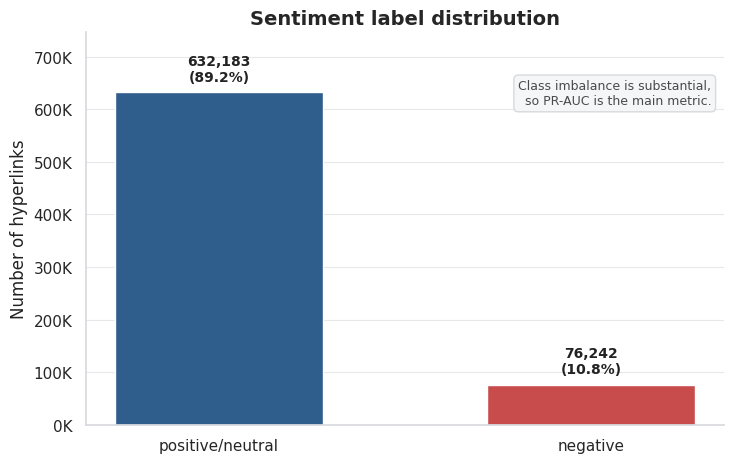

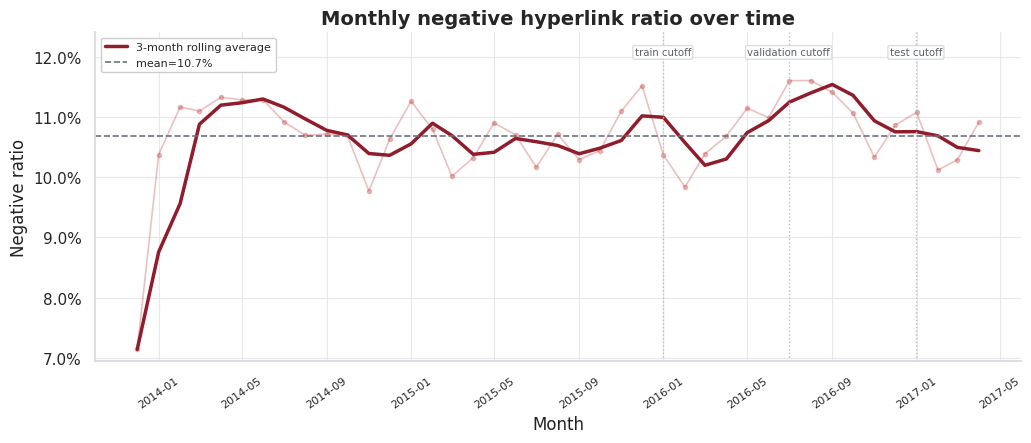

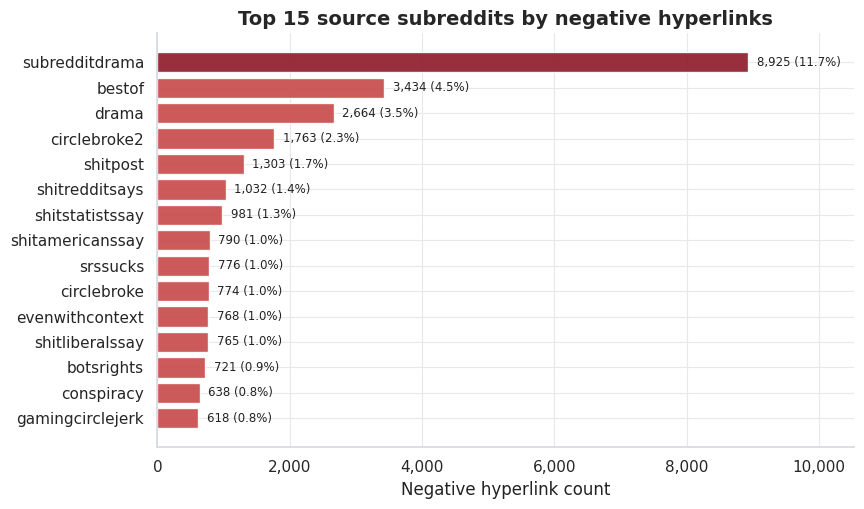

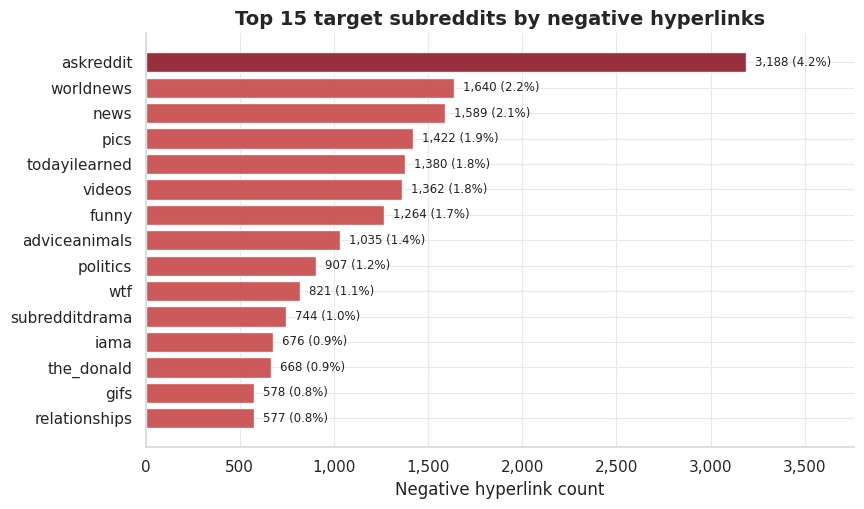

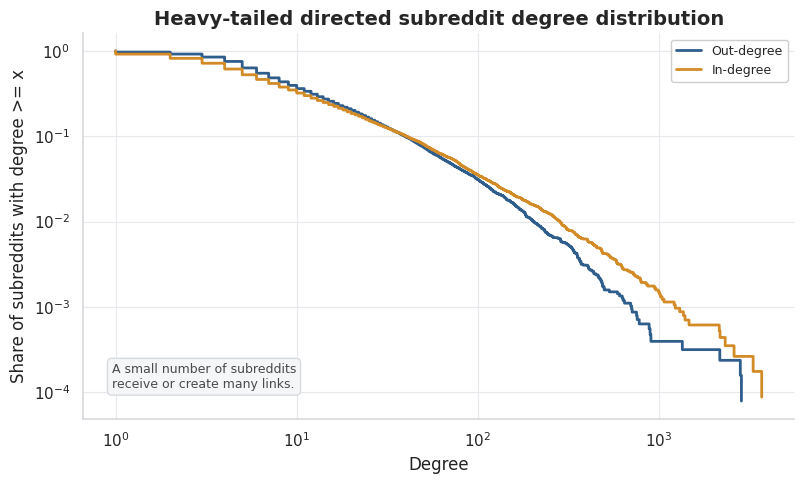

{'label_distribution': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\label_distribution.png',
 'monthly_negative_ratio': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\monthly_negative_ratio.png',
 'top_negative_subreddits': ['H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\top_negative_sources.png',
  'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\top_negative_targets.png'],
 'degree_distribution': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Expl

In [7]:
figure_paths['label_distribution'] = viz.plot_label_distribution(interactions, figure_dir, show=True)
figure_paths['monthly_negative_ratio'] = viz.plot_monthly_negative_ratio(interactions, figure_dir, show=True)
figure_paths['top_negative_subreddits'] = viz.plot_top_negative_subreddits(interactions, figure_dir, show=True)
figure_paths['degree_distribution'] = viz.plot_degree_distribution(interactions, figure_dir, show=True)
{
    'label_distribution': str(figure_paths['label_distribution']),
    'monthly_negative_ratio': str(figure_paths['monthly_negative_ratio']),
    'top_negative_subreddits': [str(path) for path in figure_paths['top_negative_subreddits']],
    'degree_distribution': str(figure_paths['degree_distribution']),
}

## 8. Community and Network Visualizations

These figures make the social-network analysis visible. They show detected communities, community-level negativity, and negative-link ratios between large communities.

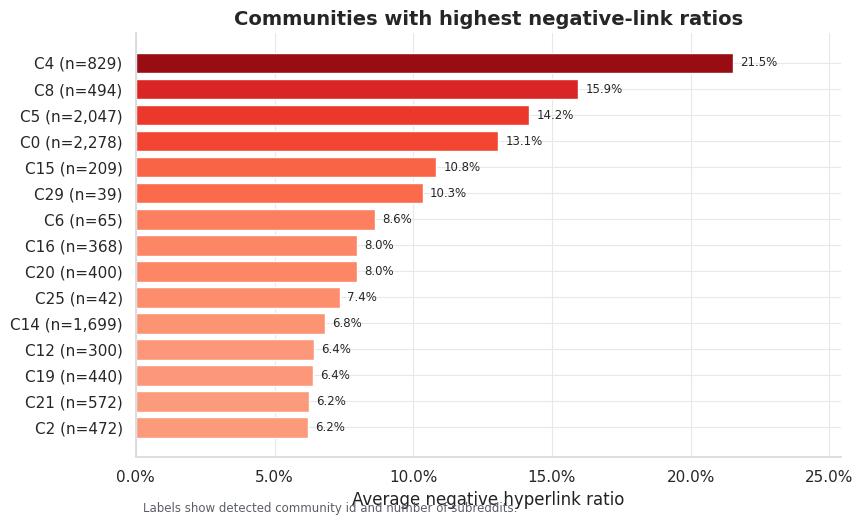

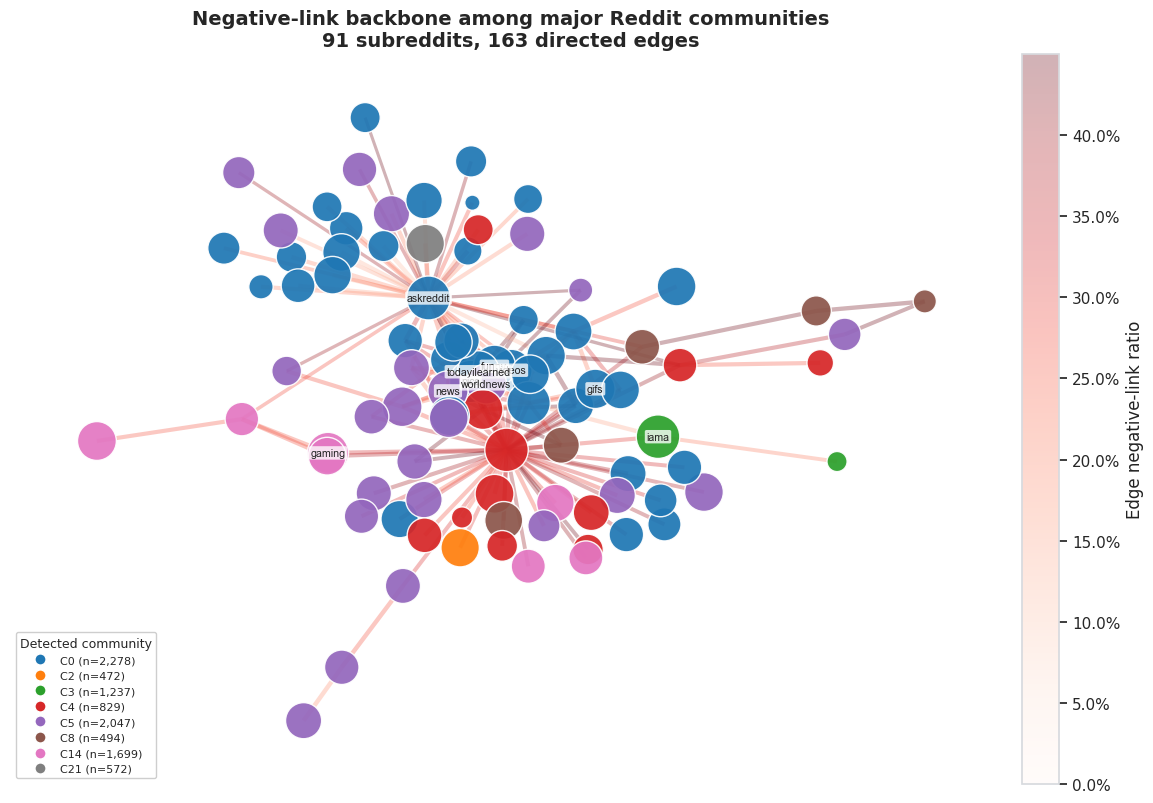

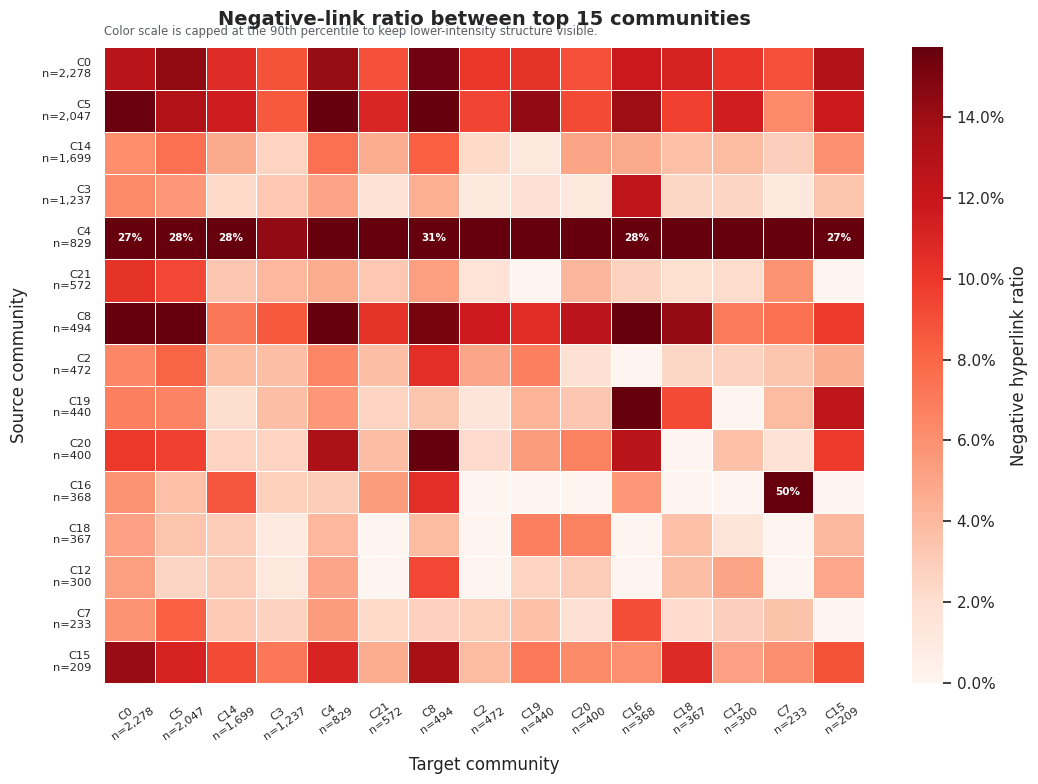

{'community_negative_ratio': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\community_negative_ratio.png',
 'community_network_sample': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\community_network_sample.png',
 'community_pair_negative_heatmap': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\community_pair_negative_heatmap.png'}

In [8]:
node_features = pd.read_csv(phase2_dir / 'phase2_node_features.csv')

figure_paths['community_negative_ratio'] = viz.plot_community_negative_ratio(node_features, figure_dir, show=True)
figure_paths['community_network_sample'] = viz.plot_community_network_sample(interactions, node_features, figure_dir, show=True)
figure_paths['community_pair_negative_heatmap'] = viz.plot_community_pair_negative_heatmap(interactions, node_features, figure_dir, show=True)

{
    'community_negative_ratio': str(figure_paths['community_negative_ratio']),
    'community_network_sample': str(figure_paths['community_network_sample']),
    'community_pair_negative_heatmap': str(figure_paths['community_pair_negative_heatmap']),
}

## 9. Generated Figure Files

This final cell lists all generated figure paths for quick checking.

In [9]:
def stringify_path(value):
    if isinstance(value, list):
        return [str(item) for item in value]
    return str(value)

{key: stringify_path(value) for key, value in figure_paths.items()}

{'model_comparison': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\model_comparison_pr_auc.png',
 'precision_recall_curve': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\precision_recall_curve.png',
 'roc_curve': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\roc_curve.png',
 'best_confusion_matrix': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\reports\\figures\\best_confusion_matrix.png',
 'feature_importance': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Expl